In [18]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from urllib.parse import quote_plus

# --------------------------
# Load DB config from .env
# --------------------------
load_dotenv()

DB_USERNAME = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

DB_PASSWORD_ENCODED = quote_plus(DB_PASSWORD)

# --------------------------
# Connect to the database
# --------------------------
engine = create_engine(
    f"postgresql+psycopg2://{DB_USERNAME}:{DB_PASSWORD_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# --------------------------
# Fetch all public tables
# --------------------------
with engine.connect() as conn:
    tables = conn.execute(
        text("SELECT table_name FROM information_schema.tables WHERE table_schema='public'")
    ).fetchall()

table_names = [t[0] for t in tables]
print("Tables in the database:", table_names)

# --------------------------
# Load each table into a pandas DataFrame and print columns
# --------------------------
dfs = {}
for table in table_names:
    dfs[table] = pd.read_sql_table(table, engine)
    print(f"\nColumns in table '{table}':")
    print(dfs[table].columns.tolist())


Tables in the database: ['argo_meta_meta', 'argo_meta_variables', 'argo_prof_meta', 'argo_prof_variables', 'argo_rtraj_meta', 'argo_rtraj_variables', 'argo_tech_meta', 'argo_tech_variables']

Columns in table 'argo_meta_meta':
['N_TRANS_SYSTEM', 'N_POSITIONING_SYSTEM', 'N_LAUNCH_CONFIG_PARAM', 'N_CONFIG_PARAM', 'N_MISSIONS', 'N_SENSOR', 'N_PARAM', 'title', 'institution', 'source', 'history', 'references', 'user_manual_version', 'Conventions']

Columns in table 'argo_meta_variables':
['name', 'dtype', 'shape', 'attributes', 'sample']

Columns in table 'argo_prof_meta':
['N_PROF', 'N_PARAM', 'N_LEVELS', 'N_CALIB', 'N_HISTORY', 'title', 'institution', 'source', 'history', 'references', 'user_manual_version', 'Conventions', 'featureType']

Columns in table 'argo_prof_variables':
['name', 'dtype', 'shape', 'attributes', 'sample']

Columns in table 'argo_rtraj_meta':
['N_PARAM', 'N_MEASUREMENT', 'N_CYCLE', 'N_HISTORY', 'title', 'institution', 'source', 'history', 'references', 'user_manual_v

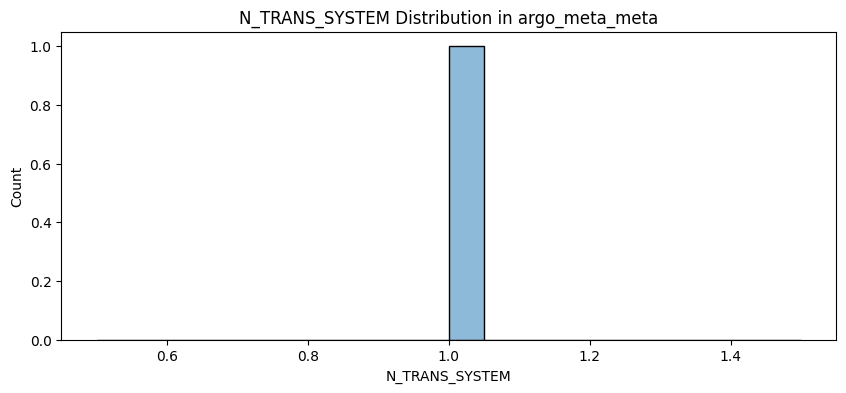

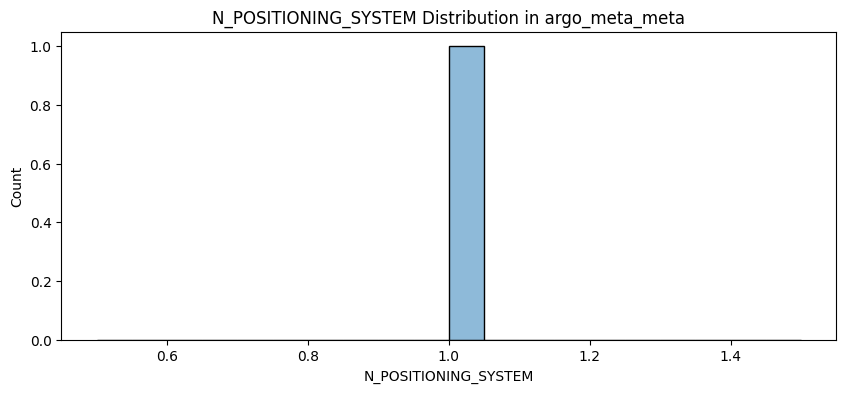

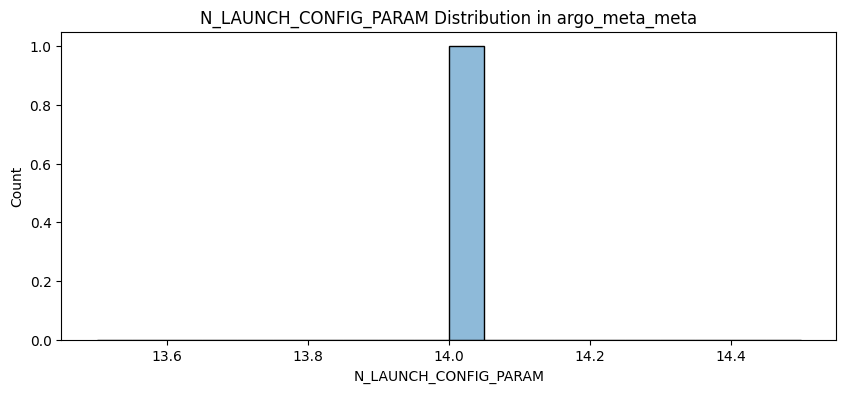

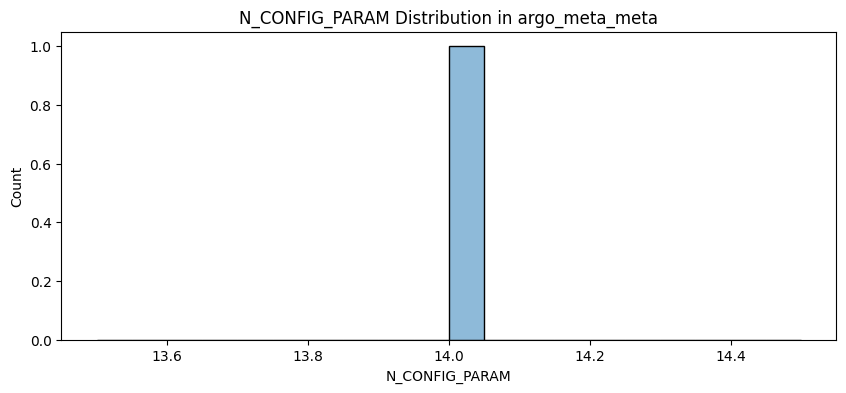

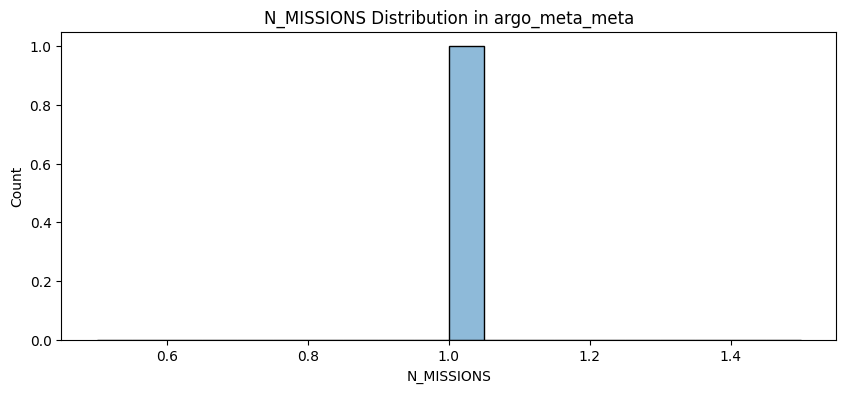

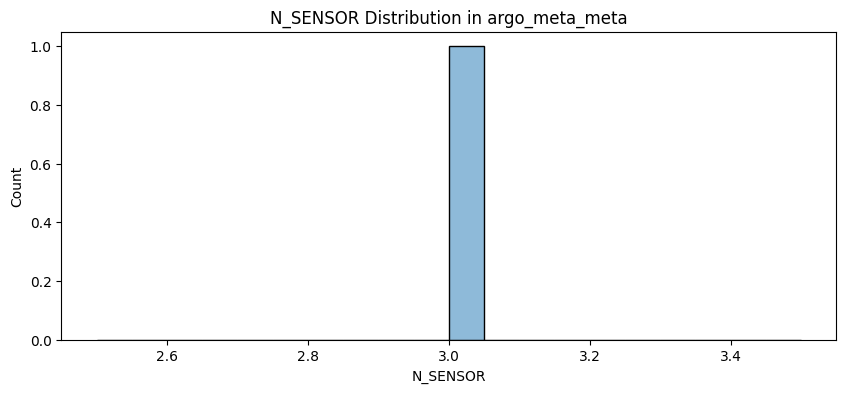

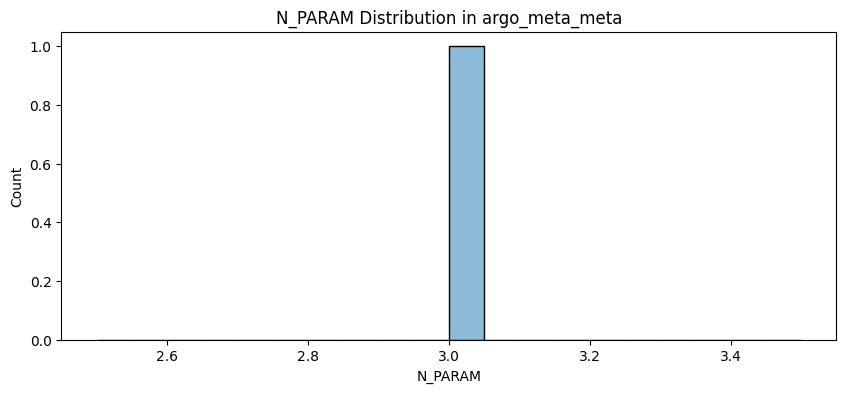

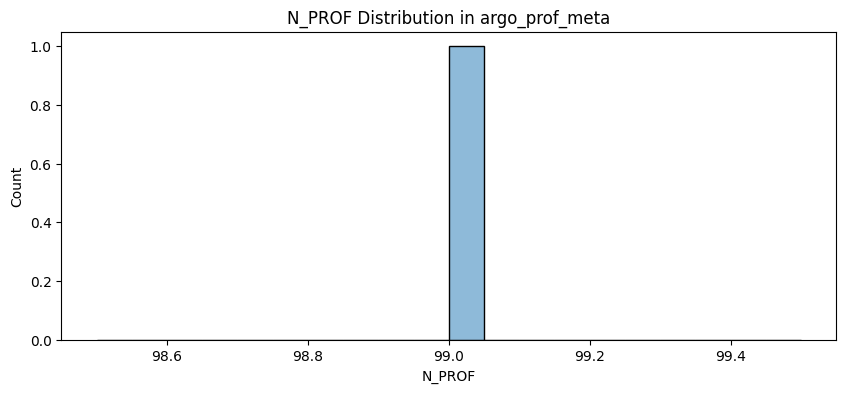

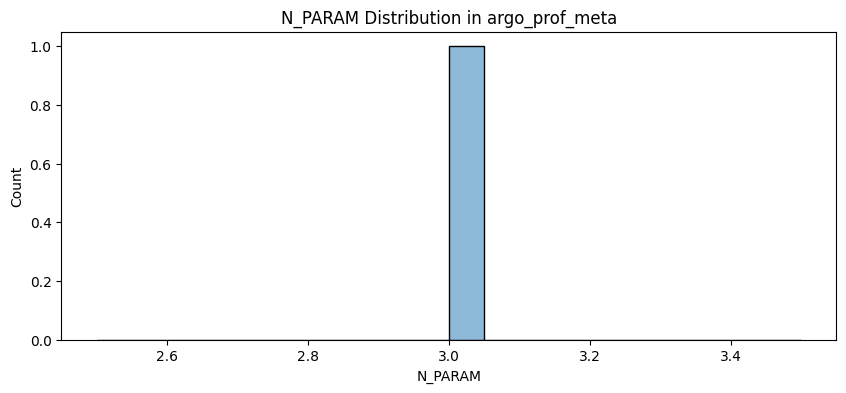

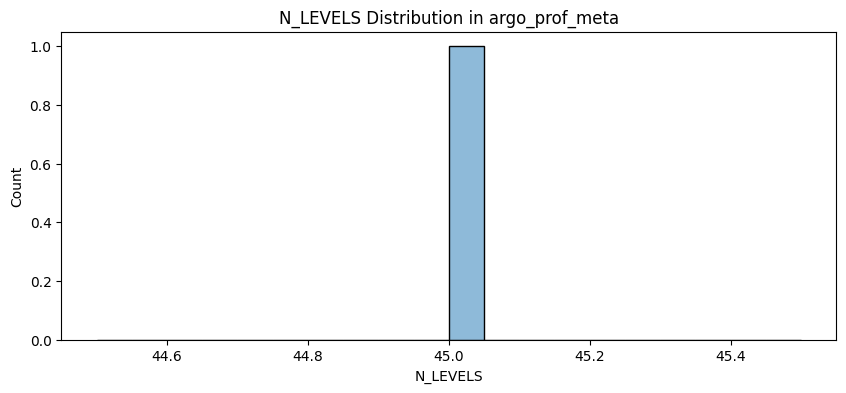

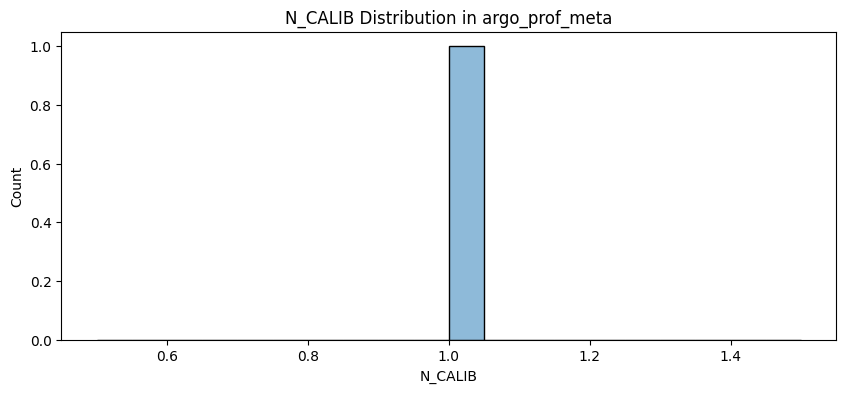

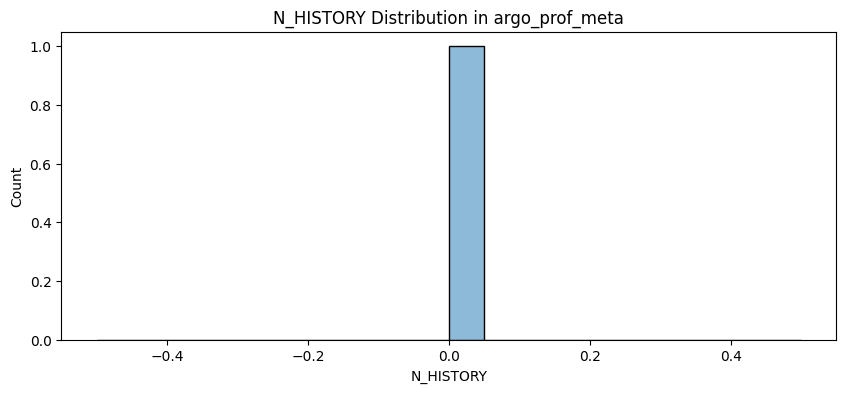

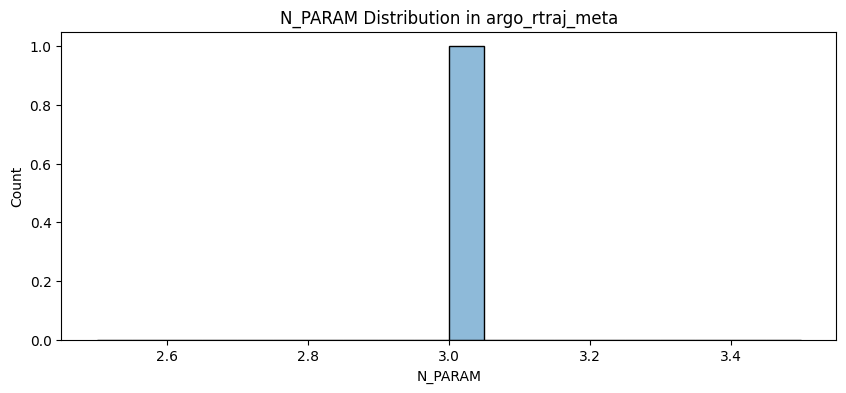

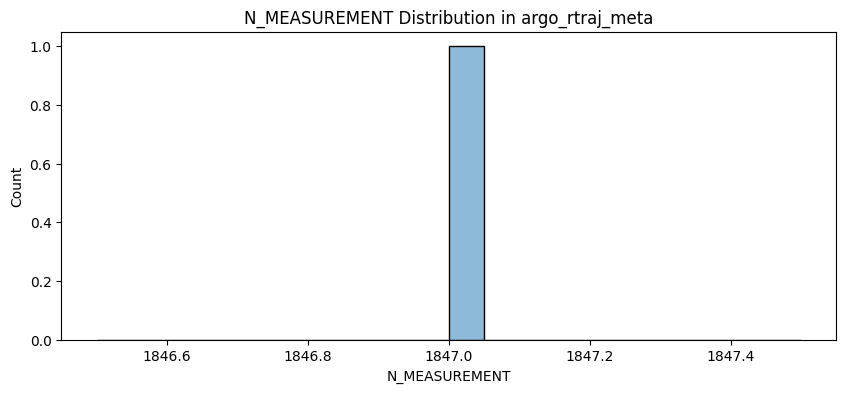

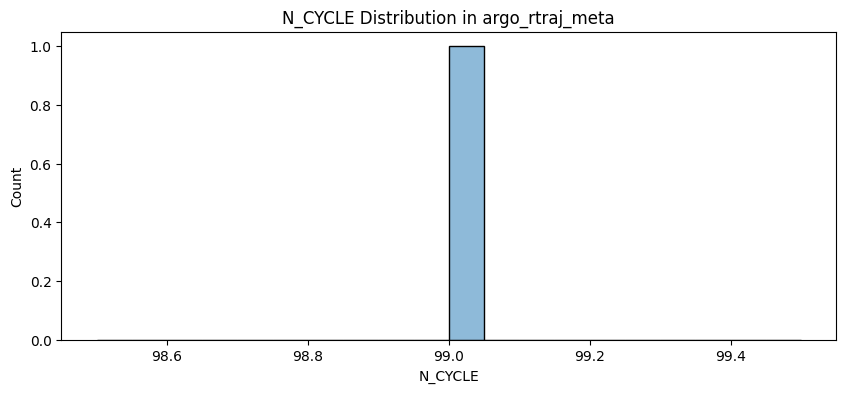

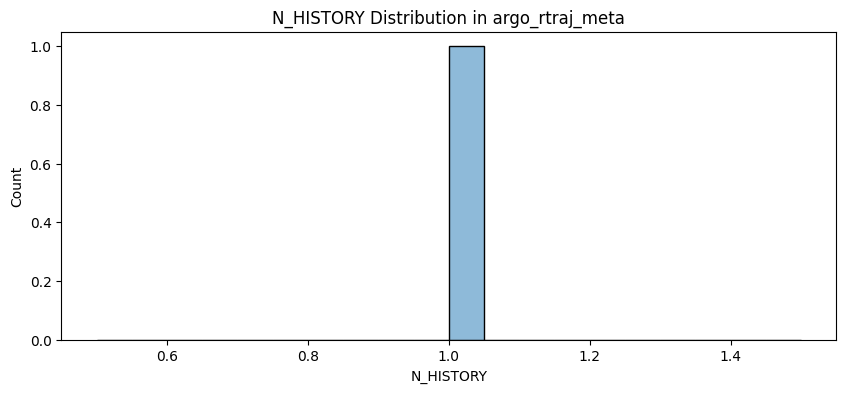

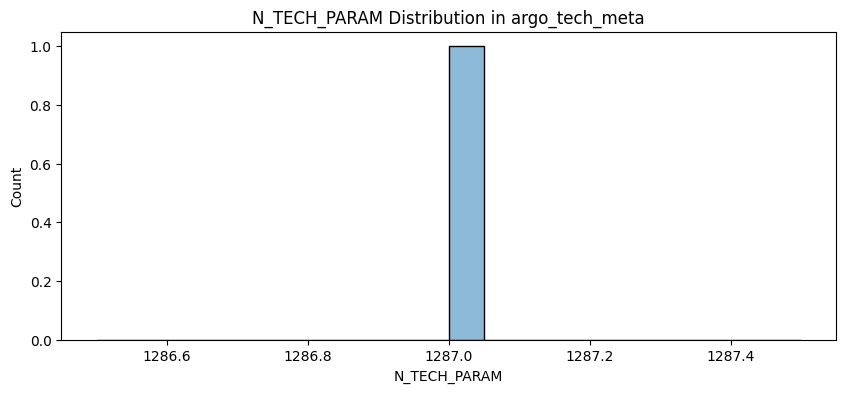

In [19]:
# Helper function to plot numeric columns
def plot_numeric_distribution(df, table_name):
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    if not numeric_cols:
        print(f"No numeric columns in {table_name}")
        return
    
    for col in numeric_cols:
        plt.figure(figsize=(10,4))
        sns.histplot(df[col], bins=20, kde=True)
        plt.title(f"{col} Distribution in {table_name}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

# Example: loop over all _meta tables
meta_tables = ['argo_meta_meta', 'argo_prof_meta', 'argo_rtraj_meta', 'argo_tech_meta']

for table in meta_tables:
    plot_numeric_distribution(dfs[table], table)


c:\Users\Admin\Documents\PROJECTS\sih\env\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\Admin\Documents\PROJECTS\sih\env\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


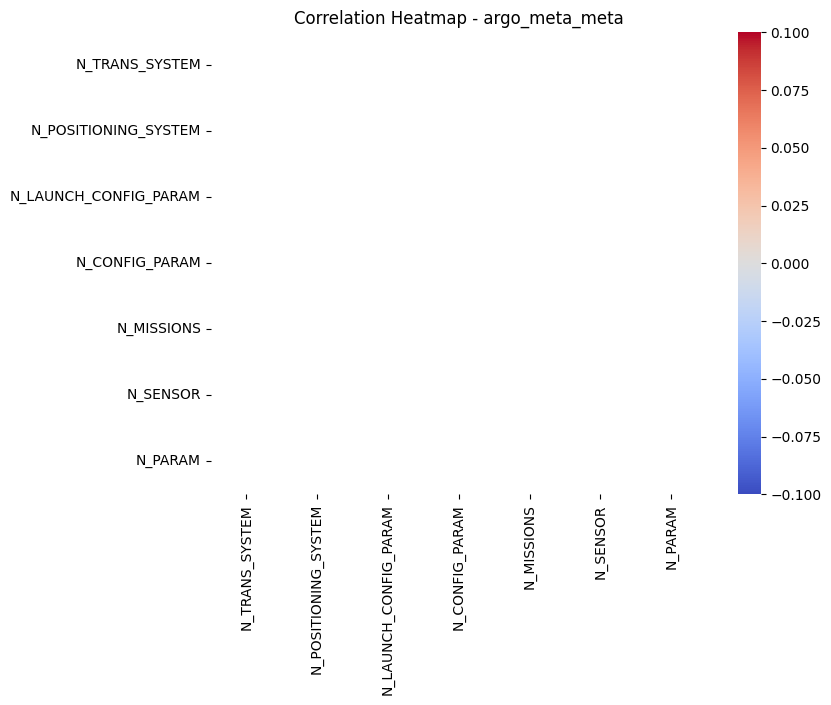

c:\Users\Admin\Documents\PROJECTS\sih\env\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\Admin\Documents\PROJECTS\sih\env\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


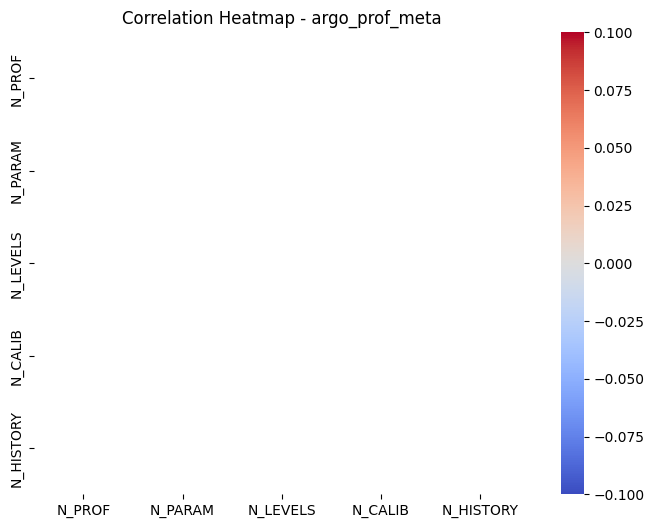

c:\Users\Admin\Documents\PROJECTS\sih\env\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\Admin\Documents\PROJECTS\sih\env\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


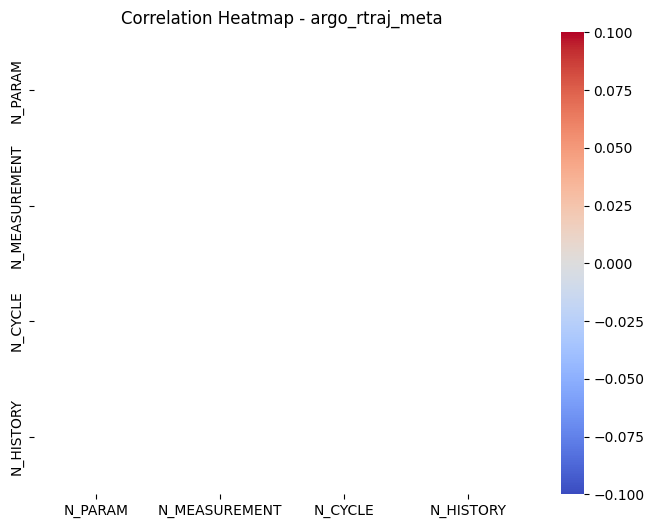

In [21]:
for table in meta_tables:
    numeric_cols = dfs[table].select_dtypes(include='number')
    if numeric_cols.shape[1] > 1:  # Only if more than 1 numeric col
        plt.figure(figsize=(8,6))
        sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
        plt.title(f"Correlation Heatmap - {table}")
        plt.show()


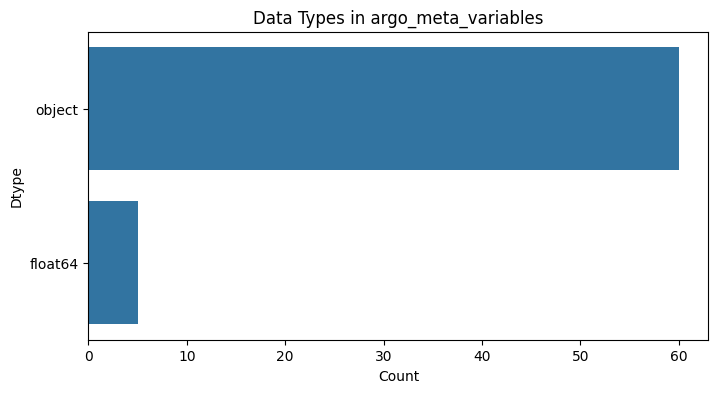

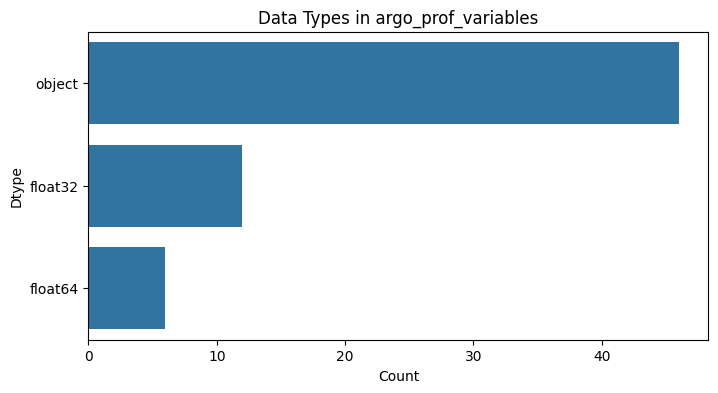

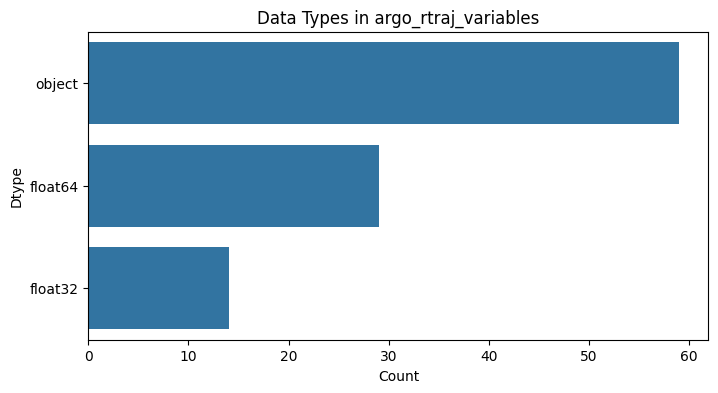

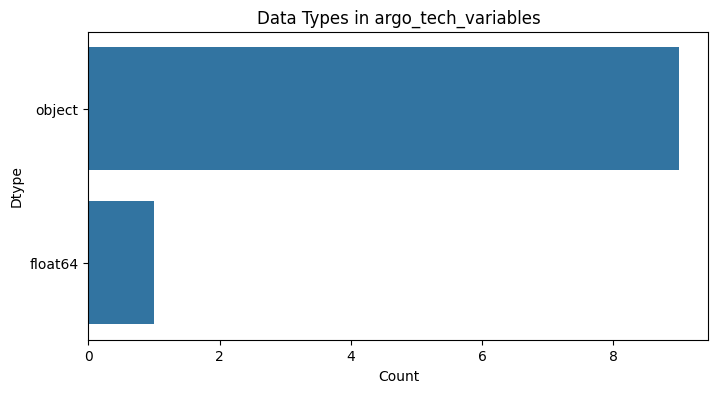

In [22]:
variable_tables = ['argo_meta_variables', 'argo_prof_variables', 'argo_rtraj_variables', 'argo_tech_variables']

for table in variable_tables:
    plt.figure(figsize=(8,4))
    sns.countplot(y=dfs[table]['dtype'], order=dfs[table]['dtype'].value_counts().index)
    plt.title(f"Data Types in {table}")
    plt.xlabel("Count")
    plt.ylabel("Dtype")
    plt.show()


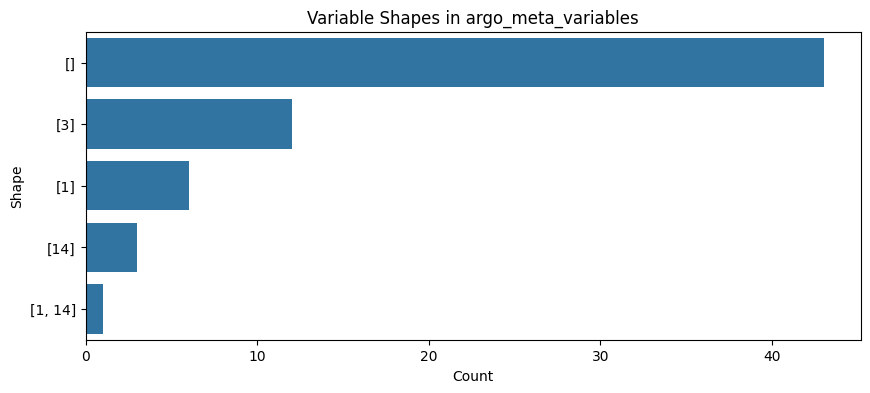

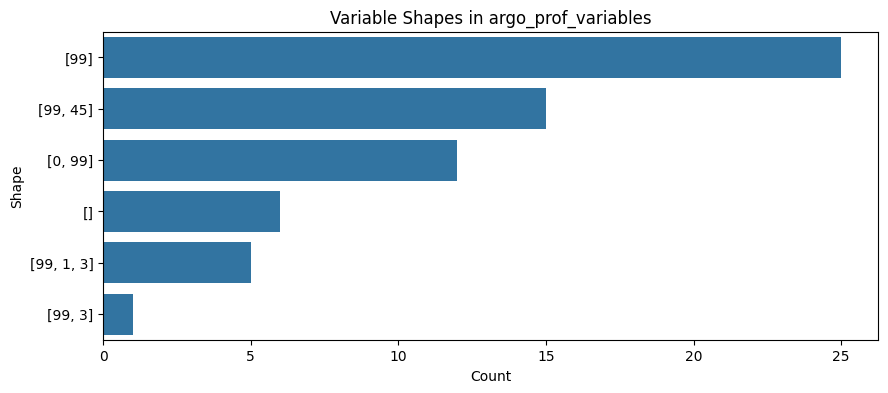

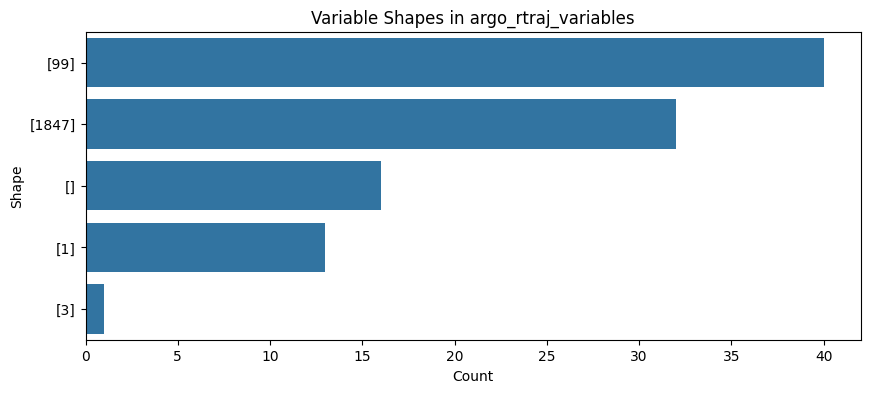

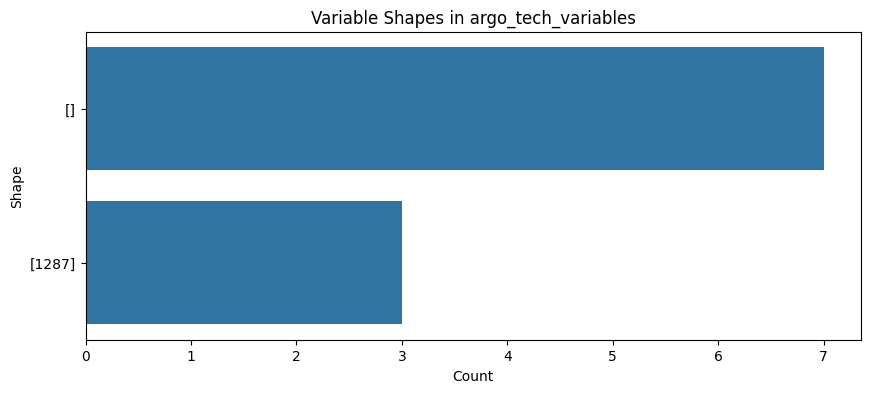

In [23]:
for table in variable_tables:
    df = dfs[table]
    df['shape_str'] = df['shape'].astype(str)  # ensure string for plotting
    plt.figure(figsize=(10,4))
    sns.countplot(y='shape_str', data=df, order=df['shape_str'].value_counts().index)
    plt.title(f"Variable Shapes in {table}")
    plt.xlabel("Count")
    plt.ylabel("Shape")
    plt.show()


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from sqlalchemy import create_engine

# -------------------------------
# PostgreSQL connection
# -------------------------------
DB_USER = "postgres"
DB_PASSWORD = "Joshua@10."
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "argo_floats"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# -------------------------------
# Step 1: Define table-to-columns mapping
# -------------------------------
# We will use the tables that actually contain profile data
table_column_map = {
    "argo_prof_variables": ["temperature", "salinity", "oxygen"],  # add more if needed
    "argo_rtraj_variables": ["temperature", "salinity"],
    "argo_tech_variables": ["tech_param1", "tech_param2"]  # placeholder
}

# -------------------------------
# Step 2: Query parsing & execution
# -------------------------------
def ask_argo(query: str):
    print("🔍 Query:", query)

    # Extract year
    year_match = re.search(r"(\d{4})", query)
    if not year_match:
        print("⚠️ Could not detect year in query!")
        return
    year = int(year_match.group(1))

    # Extract parameter (simple heuristic: look for words matching column names)
    param = None
    query_lower = query.lower()
    for cols in table_column_map.values():
        for col in cols:
            if col.lower() in query_lower:
                param = col
                break
        if param:
            break
    
    if not param:
        print("⚠️ Could not detect parameter in query!")
        return
    
    # Find which table contains this parameter
    table_name = None
    for t, cols in table_column_map.items():
        if param in cols:
            table_name = t
            break
    
    if not table_name:
        print("⚠️ Parameter not found in any table!")
        return
    
    print(f"✨ Best Match: Parameter '{param}' in table '{table_name}'")
    print(f"📌 Parsed Year: {year}")
    print(f"📌 Fetching Columns: ['profile_number', '{param}', 'depth_index']")
    
    # SQL Query
    sql_query = f"""
        SELECT profile_number, depth_index, "{param}"
        FROM {table_name}
        WHERE EXTRACT(YEAR FROM time_index) = {year}  -- replace 'time_index' with actual column
          AND "{param}" IS NOT NULL
        ORDER BY profile_number, depth_index
    """
    
    df = pd.read_sql(sql_query, engine)
    if df.empty:
        print("⚠️ No data found for this parameter/year.")
        return
    
    print("✅ SQL Results (first 5 rows):")
    print(df.head())

    # Plot first 5 profiles
    plt.figure(figsize=(6,8))
    for profile in df["profile_number"].unique()[:5]:
        prof_data = df[df["profile_number"] == profile]
        plt.plot(prof_data[param], prof_data["depth_index"], label=f"Profile {profile}")

    plt.gca().invert_yaxis()
    plt.xlabel(param.capitalize())
    plt.ylabel("Depth Index")
    plt.title(f"{param.capitalize()} Profiles for {year}")
    plt.legend()
    plt.show()


# -------------------------------
# Step 3: Ask user for query
# -------------------------------
user_query = input("Enter your query about Argo data: ")
ask_argo(user_query)


KeyboardInterrupt: Interrupted by user